In [131]:
import gzip, h5py, io

with gzip.open('pulse_4b_U2_output.h5.gz', 'rb') as f:
    data = f.read()

with h5py.File(io.BytesIO(data), 'r') as h5f:
    Rs = h5f['Rs'][:]
    nks = h5f['nks'][:]
    deltas = h5f['deltas'][:]

nbath = 8

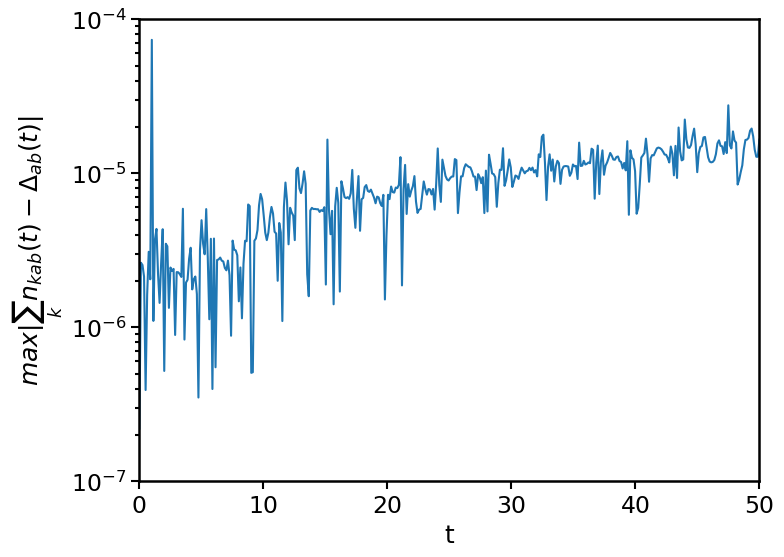

In [116]:
import numpy as np
import matplotlib.pyplot as plt
### check constraints after letting \Lambda = 0
t = np.linspace(0, 50, 400)
nks_summed = nks.reshape(400, 500, 8, 8).sum(axis=1) /500
diff = nks_summed - deltas   # shape (400, 8, 8)
max_violation = np.max(np.abs(diff), axis=(1,2))   # shape (400,) — elementwise worst-case per i

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(t, max_violation)
ax.set_yscale('log')
ax.set_xlabel('t', fontsize=18)
ax.set_ylabel(r'$max |\sum_k n_{kab}(t) - \Delta_{ab}(t)|$', fontsize=18)
#ax.axhline(1e-6, color='r', linestyle='--', label='tol')
#ax.legend(fontsize=16)
ax.set_xlim(0, 50)
ax.set_ylim(1e-7, 1e-4)
ax.tick_params(axis='both', which='major', labelsize=17, width=1.5, length=6)
ax.tick_params(axis='both', which='minor', width=1.5, length=3)

for spine in ax.spines.values():
    spine.set_linewidth(1.8)
plt.show()

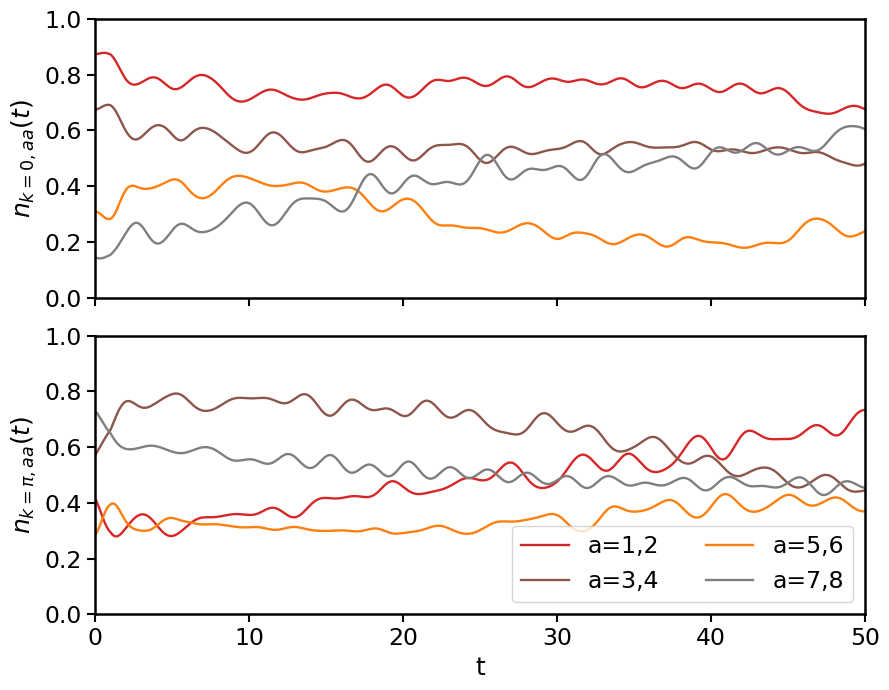

In [129]:
fig, axes = plt.subplots(2, 1, figsize=(9,7), sharex=True)
orbitals = [0, 2, 4, 6]
colors = ['C3', 'C5', 'C1', 'C7']
for a, c in zip(orbitals, colors):
    axes[0].plot(t, nks[0::500, a, a].real , label=f'a={a+1},{a+2}', color=c, lw=1.7)
    axes[1].plot(t, nks[500//2::500, a, a].real , label=f'a={a+1},{a+2}', color=c, lw=1.7)

axes[0].set_ylabel(r'$n_{k=0,aa}(t) $', fontsize=18)
axes[1].set_ylabel(r'$n_{k=\pi,aa}(t) $', fontsize=18)
axes[1].set_xlabel('t', fontsize=18)
axes[0].set_xlim(0, 50)
axes[0].set_ylim(0, 1)
axes[1].set_ylim(0, 1)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=17, width=1.5, length=6)
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

axes[1].legend(fontsize=17, ncol=2, loc='best')
plt.tight_layout()
plt.show()

In [153]:
nimp = 4
nbath = 8
nks_new = nks.reshape(400, 500, nbath, nbath)
Nk = np.zeros((400, 500), dtype = np.complex128)

# Nkab
t = np.linspace(0,40,400)
for i in range(len(t)):
    for j in range(500):
        for a in range(nbath):
            for b in range(nbath):
                Nk[i, j] += nks_new[i, j, a, b] * Rs[i, a, 3] * (Rs[i].conj().T)[3, b]  
                       # + nks_new[i, j, a, b] * vlist[j] * Rs[i, a, 1] * (Rs[i].conj().T)[1, b]) 

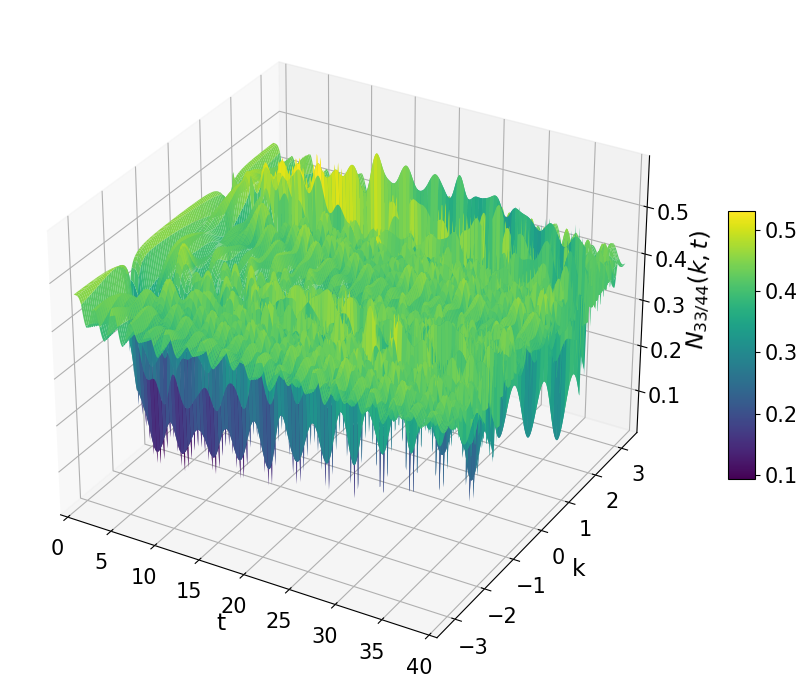

In [154]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401, needed for 3d projection

# your existing arrays
t = np.linspace(0, 40, 400)
k = np.linspace(-np.pi,np.pi, 500)   # replace with your actual k-grid if different

T, K = np.meshgrid(t, k, indexing='ij')  # shape (400, 500), matches Nk

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T, K, Nk.real, cmap='viridis',
                        linewidth=0, antialiased=True, rstride=4, cstride=4)

ax.set_xlabel('t', fontsize=17)
ax.set_ylabel('k', fontsize=17)
ax.set_zlabel('$N_{33/44}(k,t)$', fontsize=17)
#ax.set_title('N(k,t)')
ax.set_xlim(0,40)
ax.tick_params(axis='both', which='major', labelsize=15, width=1.5, length=6)

cbar = fig.colorbar(surf, shrink=0.4, aspect=10)
cbar.ax.tick_params(labelsize=15)
plt.tight_layout()
#plt.savefig('Nkt_3d.png', dpi=150)
plt.show()